# Data Collection

--> Dataset has generated successfully with help of AI and some manual research

-->Now we need to perform data analysis and EDA

**Importing necessary libraries**

In [1]:
# Cell 1: Import core operational and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import ExtraTreesClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import time

from sklearn.metrics import (roc_auc_score, accuracy_score, balanced_accuracy_score, 
                             f1_score, precision_score, recall_score, matthews_corrcoef)



# Configure visualization defaults for clear, scannable terminal reporting
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment successfully initialized. Ready to load ground handling assets.")

Environment successfully initialized. Ready to load ground handling assets.


**Loading Datasets**

In [2]:
train_df = pd.read_csv('gse_availability_train.csv')
val_df = pd.read_csv('gse_availability_validation.csv')
test_df = pd.read_csv('gse_availability_test.csv')

# Print out the dataset dimensions to verify the split
print("=== Ground Handling Dataset Shapes ===")
print(f"Training Split Rows:    {train_df.shape[0]:>6} rows | Columns: {train_df.shape[1]}")
print(f"Validation Split Rows:  {val_df.shape[0]:>6} rows | Columns: {val_df.shape[1]}")
print(f"Testing Split Rows:     {test_df.shape[0]:>6} rows | Columns: {test_df.shape[1]}")
print("=======================================")

=== Ground Handling Dataset Shapes ===
Training Split Rows:     21000 rows | Columns: 21
Validation Split Rows:    4500 rows | Columns: 21
Testing Split Rows:       4500 rows | Columns: 21


**Data Integrity Audit**

In [3]:

def run_deep_integrity_audit(df, split_name):
    print(f"=== DEEP INTEGRITY AUDIT: {split_name.upper()} ===")
    
    # 1. Standard Data Hygiene Checks
    null_count = df.isnull().sum().sum()
    duplicate_count = df.duplicated().sum()
    
    # 2. Operational Boundary Violations Checks
    # Battery bounds check (Must stay between 0% and 100%)
    battery_violations = df[(df['avg_battery_soc_zone'] < 0.0) | (df['avg_battery_soc_zone'] > 100.0)].shape[0]
    
    # Fleet utilization bounds check (Must stay between 0.0 and 1.0)
    utilization_violations = df[(df['fleet_utilization_ratio'] < 0.0) | (df['fleet_utilization_ratio'] > 1.0)].shape[0]
    
    # Negative values check for physical asset demand and inventory counters
    negative_asset_violations = df[
        (df['required_pushback_tugs'] < 0) | (df['required_belt_loaders'] < 0) | (df['required_gpus'] < 0) |
        (df['avail_tugs_zone'] < 0) | (df['avail_loaders_zone'] < 0) | (df['avail_gpus_zone'] < 0) |
        (df['concurrent_arrivals_30min'] < 0) | (df['gse_operator_on_duty_count'] < 0)
    ].shape[0]

    # Print reporting summaries
    print(f"  - Missing Cells (Nulls):         {null_count}")
    print(f"  - Duplicate Rows:                {duplicate_count}")
    print(f"  - Battery Out-of-Bounds (>100/<0): {battery_violations}")
    print(f"  - Fleet Util Out-of-Bounds (>1.0): {utilization_violations}")
    print(f"  - Negative Asset/Staff Counts:   {negative_asset_violations}")
    
    if (null_count == 0) and (duplicate_count == 0) and (battery_violations == 0) and (utilization_violations == 0) and (negative_asset_violations == 0):
        print(f"STATUS: PASS - {split_name} data is operationally sound and intact.\n")
    else:
        print(f"STATUS: WARNING - Anomaly detected in {split_name} split. Check rows.\n")

# Run the deep audit sequentially across your data matrices
run_deep_integrity_audit(train_df, "Training Split")
run_deep_integrity_audit(val_df, "Validation Split")
run_deep_integrity_audit(test_df, "Testing Split")

=== DEEP INTEGRITY AUDIT: TRAINING SPLIT ===
  - Missing Cells (Nulls):         0
  - Duplicate Rows:                0
  - Battery Out-of-Bounds (>100/<0): 0
  - Fleet Util Out-of-Bounds (>1.0): 0
  - Negative Asset/Staff Counts:   0
STATUS: PASS - Training Split data is operationally sound and intact.

=== DEEP INTEGRITY AUDIT: VALIDATION SPLIT ===
  - Missing Cells (Nulls):         0
  - Duplicate Rows:                0
  - Battery Out-of-Bounds (>100/<0): 0
  - Fleet Util Out-of-Bounds (>1.0): 0
  - Negative Asset/Staff Counts:   0
STATUS: PASS - Validation Split data is operationally sound and intact.

=== DEEP INTEGRITY AUDIT: TESTING SPLIT ===
  - Missing Cells (Nulls):         0
  - Duplicate Rows:                0
  - Battery Out-of-Bounds (>100/<0): 0
  - Fleet Util Out-of-Bounds (>1.0): 0
  - Negative Asset/Staff Counts:   0
STATUS: PASS - Testing Split data is operationally sound and intact.



# EDA

In [4]:
import warnings
warnings.filterwarnings('ignore')

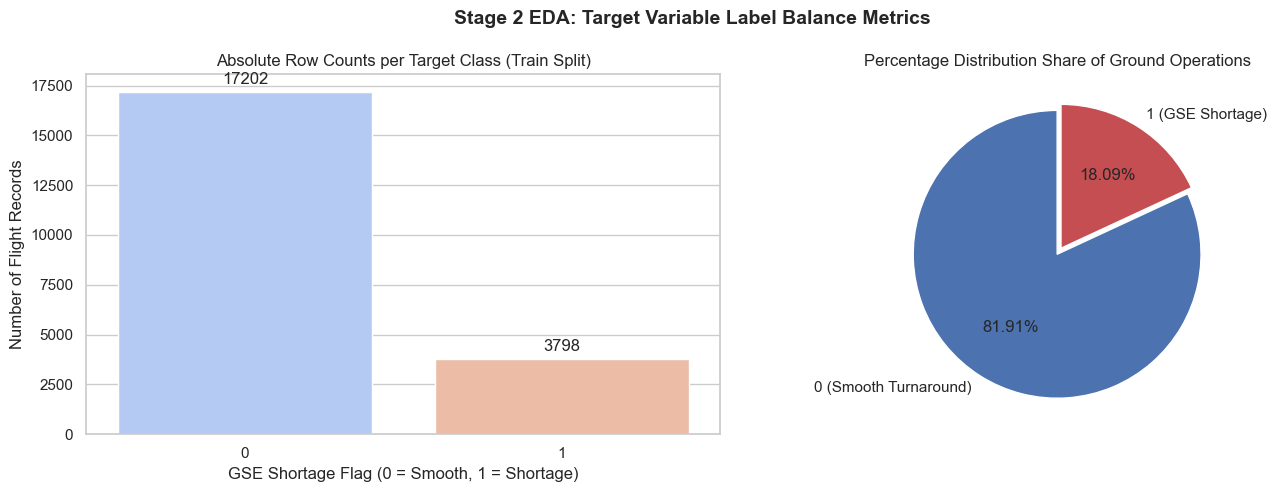

In [5]:
# Create a side-by-side visualization plot frame
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Absolute Count Bar Chart
sns.countplot(x='gse_shortage_flag', data=train_df, ax=axes[0], palette='coolwarm')
axes[0].set_title('Absolute Row Counts per Target Class (Train Split)')
axes[0].set_xlabel('GSE Shortage Flag (0 = Smooth, 1 = Shortage)')
axes[0].set_ylabel('Number of Flight Records')

# Annotate raw value bars with exact numbers
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', label_type='edge', padding=3)

# Plot 2: Relative Share Percentage Pie Chart
target_shares = train_df['gse_shortage_flag'].value_counts()
axes[1].pie(
    target_shares, 
    labels=['0 (Smooth Turnaround)', '1 (GSE Shortage)'], 
    autopct='%1.2f%%', 
    startangle=90, 
    colors=['#4c72b0', '#c44e52'],
    explode=(0, 0.05)
)
axes[1].set_title('Percentage Distribution Share of Ground Operations')

plt.suptitle('Stage 2 EDA: Target Variable Label Balance Metrics', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

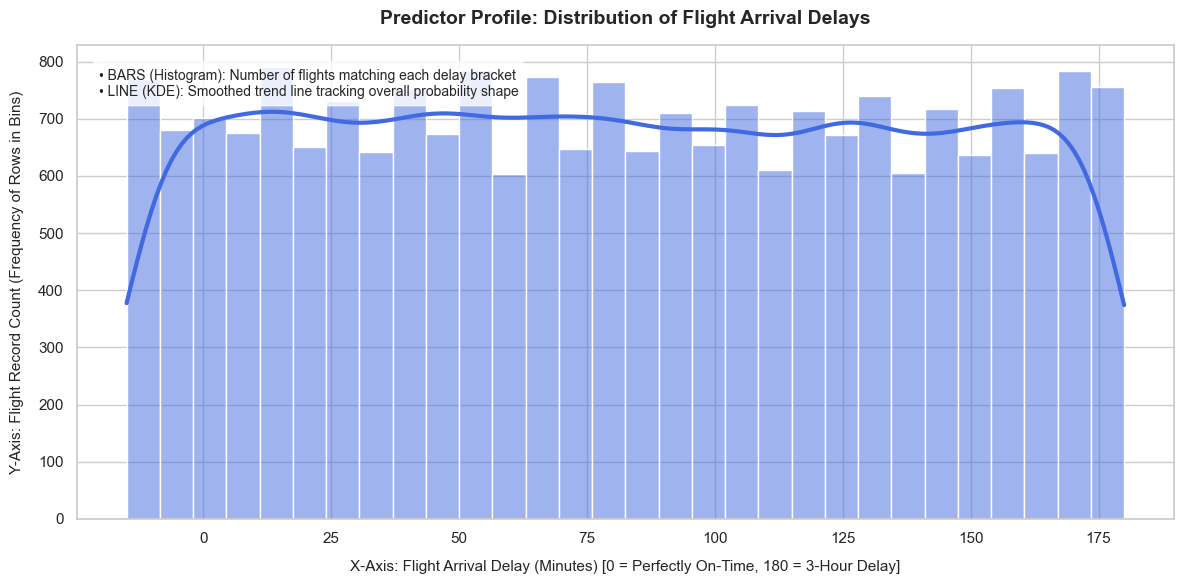

In [6]:

plt.figure(figsize=(12, 6))

# Plot the distribution with distinct visual properties
sns.histplot(
    data=train_df, 
    x='arrival_delay_mins', 
    kde=True, 
    color='royalblue', 
    bins=30,
    line_kws={'linewidth': 3, 'color': 'darkblue'}
)

# Explicitly label every component for absolute clarity
plt.title('Predictor Profile: Distribution of Flight Arrival Delays', fontsize=14, pad=15, weight='bold')
plt.xlabel('X-Axis: Flight Arrival Delay (Minutes) [0 = Perfectly On-Time, 180 = 3-Hour Delay]', fontsize=11, labelpad=10)
plt.ylabel('Y-Axis: Flight Record Count (Frequency of Rows in Bins)', fontsize=11, labelpad=10)

# Add clear annotation text explaining how to read the components
plt.text(0.02, 0.95, '• BARS (Histogram): Number of flights matching each delay bracket\n• LINE (KDE): Smoothed trend line tracking overall probability shape', 
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

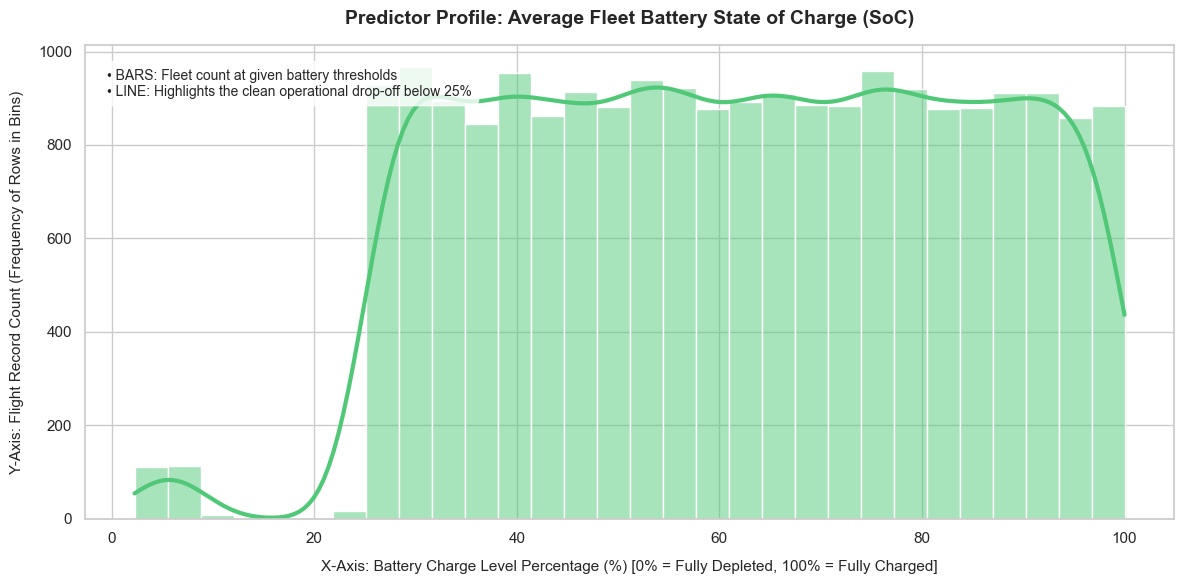

In [7]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=train_df, 
    x='avg_battery_soc_zone', 
    kde=True, 
    color='#50C878',  # Using a rich green for battery tracking
    bins=30,
    line_kws={'linewidth': 3, 'color': 'darkgreen'}
)

plt.title('Predictor Profile: Average Fleet Battery State of Charge (SoC)', fontsize=14, pad=15, weight='bold')
plt.xlabel('X-Axis: Battery Charge Level Percentage (%) [0% = Fully Depleted, 100% = Fully Charged]', fontsize=11, labelpad=10)
plt.ylabel('Y-Axis: Flight Record Count (Frequency of Rows in Bins)', fontsize=11, labelpad=10)

plt.text(0.02, 0.95, '• BARS: Fleet count at given battery thresholds\n• LINE: Highlights the clean operational drop-off below 25%', 
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

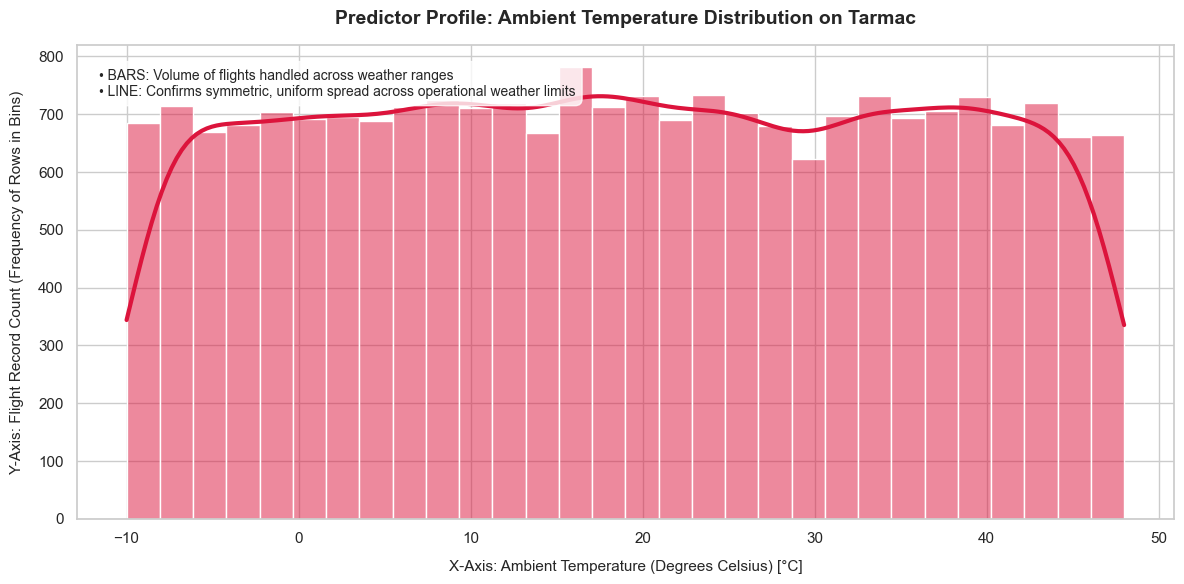

In [8]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=train_df, 
    x='ambient_temperature_c', 
    kde=True, 
    color='crimson',  # Using a warm color for temperature tracking
    bins=30,
    line_kws={'linewidth': 3, 'color': 'darkred'}
)

plt.title('Predictor Profile: Ambient Temperature Distribution on Tarmac', fontsize=14, pad=15, weight='bold')
plt.xlabel('X-Axis: Ambient Temperature (Degrees Celsius) [°C]', fontsize=11, labelpad=10)
plt.ylabel('Y-Axis: Flight Record Count (Frequency of Rows in Bins)', fontsize=11, labelpad=10)

plt.text(0.02, 0.95, '• BARS: Volume of flights handled across weather ranges\n• LINE: Confirms symmetric, uniform spread across operational weather limits', 
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [9]:

# Identify all numerical columns automatically, excluding IDs and Target
numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'flight_id' in numerical_cols: numerical_cols.remove('flight_id')
if 'gse_shortage_flag' in numerical_cols: numerical_cols.remove('gse_shortage_flag')

print("=== STAGE 2 EDA: COMPLETE FEATURE SKEWNESS PROFILE ===")
print(f"{'Feature Name':<30} | {'Skewness':<8} | {'Shape Classification'}")
print("-" * 70)

# Loop through and evaluate every single numerical predictor
for col in numerical_cols:
    skew_val = train_df[col].skew()
    
    # Classify the shape profile based on standard statistical thresholds
    if abs(skew_val) < 0.1:
        classification = "Symmetric / Uniform"
    elif skew_val >= 0.1 and skew_val <= 0.5:
        classification = "Mild Right-Skew"
    elif skew_val > 0.5:
        classification = "Highly Right-Skewed"
    elif skew_val <= -0.1 and skew_val >= -0.5:
        classification = "Mild Left-Skew"
    else:
        classification = "Highly Left-Skewed"
        
    print(f"{col:<30} | {skew_val:>8.3f} | {classification}")
print("=" * 70)

=== STAGE 2 EDA: COMPLETE FEATURE SKEWNESS PROFILE ===
Feature Name                   | Skewness | Shape Classification
----------------------------------------------------------------------
arrival_delay_mins             |    0.018 | Symmetric / Uniform
required_pushback_tugs         |    0.866 | Highly Right-Skewed
required_belt_loaders          |    0.591 | Highly Right-Skewed
required_gpus                  |    0.866 | Highly Right-Skewed
concurrent_arrivals_30min      |    0.676 | Highly Right-Skewed
total_zone_baggage_volume      |    0.774 | Highly Right-Skewed
avail_tugs_zone                |    0.193 | Mild Right-Skew
avail_loaders_zone             |    0.038 | Symmetric / Uniform
avail_gpus_zone                |    0.205 | Mild Right-Skew
avg_battery_soc_zone           |   -0.095 | Symmetric / Uniform
fleet_utilization_ratio        |    0.234 | Mild Right-Skew
gse_operator_on_duty_count     |    0.454 | Mild Right-Skew
active_fault_code_count_zone   |   -0.002 | Symmetric / U

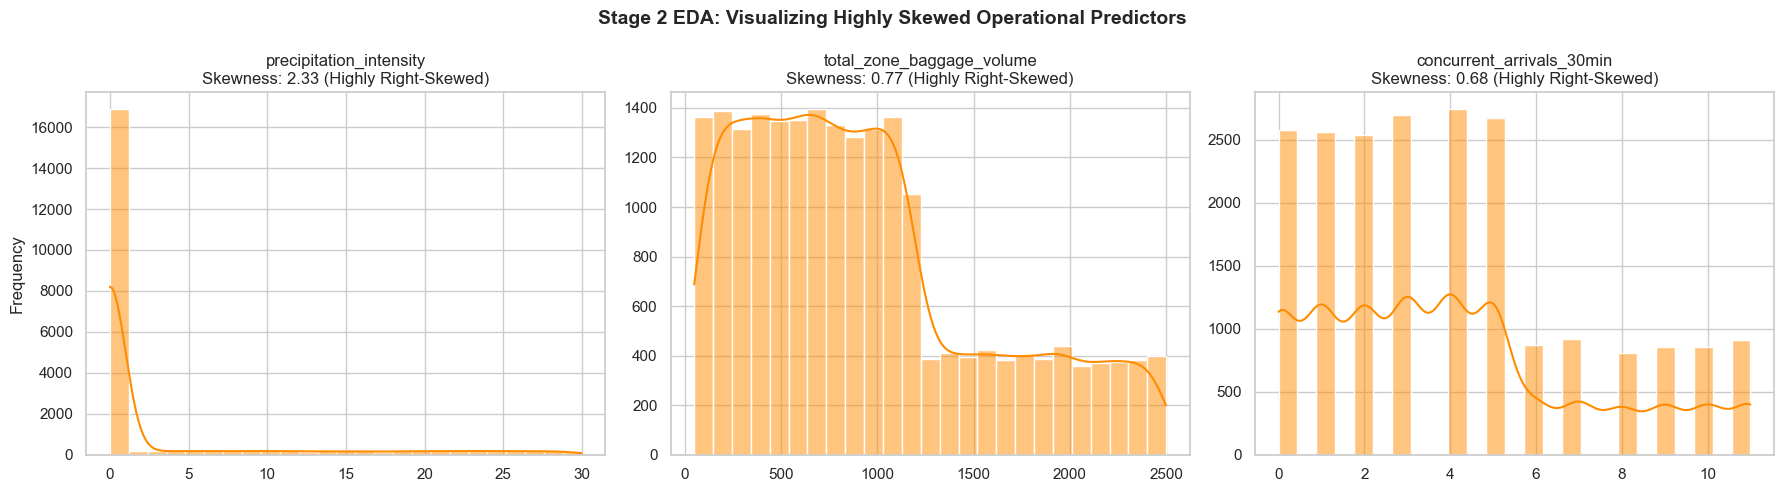

In [10]:
# Cell 10: Visualizing Highly Skewed vs. Symmetric Predictor Profiles

# We pick three highly right-skewed features to visualize their mountain-and-tail shapes
skewed_features = ['precipitation_intensity', 'total_zone_baggage_volume', 'concurrent_arrivals_30min']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(skewed_features):
    skew_val = train_df[col].skew()
    
    # Plot using a warm color to represent the high skewness profile
    sns.histplot(data=train_df, x=col, kde=True, ax=axes[i], color='darkorange', bins=25)
    
    axes[i].set_title(f'{col}\nSkewness: {skew_val:.2f} (Highly Right-Skewed)')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency' if i == 0 else '')

plt.suptitle('Stage 2 EDA: Visualizing Highly Skewed Operational Predictors', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

In [11]:

# Create custom bins to separate clear weather from mild, medium, and extreme rain
rain_bins = [-1, 0.1, 5, 15, 35]
rain_labels = ['Clear Weather (0mm)', 'Light Rain (0.1-5mm)', 'Moderate Rain (5-15mm)', 'Heavy/Severe Storm (>15mm)']

# Segment the training data into these weather brackets
train_df['rain_bracket'] = pd.cut(train_df['precipitation_intensity'], bins=rain_bins, labels=rain_labels)

# Calculate the total flights and the true shortage percentage for each bracket
risk_profile = train_df.groupby('rain_bracket', observed=False).agg(
    Total_Flights=('gse_shortage_flag', 'count'),
    Shortage_Count=('gse_shortage_flag', 'sum'),
    True_Shortage_Risk_Pct=('gse_shortage_flag', lambda x: x.mean() * 100)
)

print("=== STAGE 3 EDA: THE REAL OPERATIONAL RISK OF RAIN ===")
print(risk_profile.round(2))
print("======================================================")

# Clean up temporary column so it doesn't alter our clean dataframe features
train_df.drop(columns=['rain_bracket'], inplace=True)

=== STAGE 3 EDA: THE REAL OPERATIONAL RISK OF RAIN ===
                            Total_Flights  Shortage_Count  \
rain_bracket                                                
Clear Weather (0mm)                 16701            2896   
Light Rain (0.1-5mm)                  712             110   
Moderate Rain (5-15mm)               1461             297   
Heavy/Severe Storm (>15mm)           2126             495   

                            True_Shortage_Risk_Pct  
rain_bracket                                        
Clear Weather (0mm)                          17.34  
Light Rain (0.1-5mm)                         15.45  
Moderate Rain (5-15mm)                       20.33  
Heavy/Severe Storm (>15mm)                   23.28  


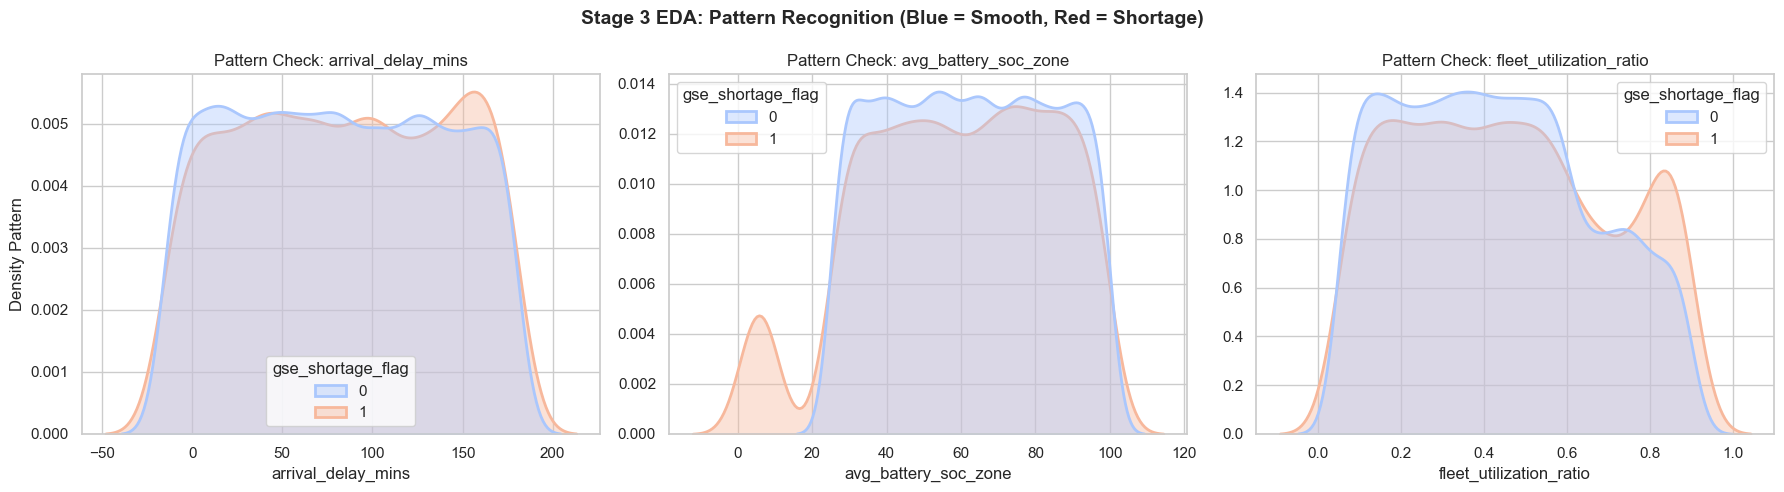

In [12]:
# Cell 12: Revealing Hidden Patterns via Target Stratification

features_to_check = ['arrival_delay_mins', 'avg_battery_soc_zone', 'fleet_utilization_ratio']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(features_to_check):
    # Hue splits the data by the shortage flag, showing the two operational states
    sns.kdeplot(
        data=train_df, 
        x=col, 
        hue='gse_shortage_flag', 
        fill=True, 
        common_norm=False, 
        palette='coolwarm', 
        alpha=0.4, 
        ax=axes[i],
        linewidth=2
    )
    axes[i].set_title(f'Pattern Check: {col}')
    axes[i].set_ylabel('Density Pattern' if i == 0 else '')

plt.suptitle('Stage 3 EDA: Pattern Recognition (Blue = Smooth, Red = Shortage)', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

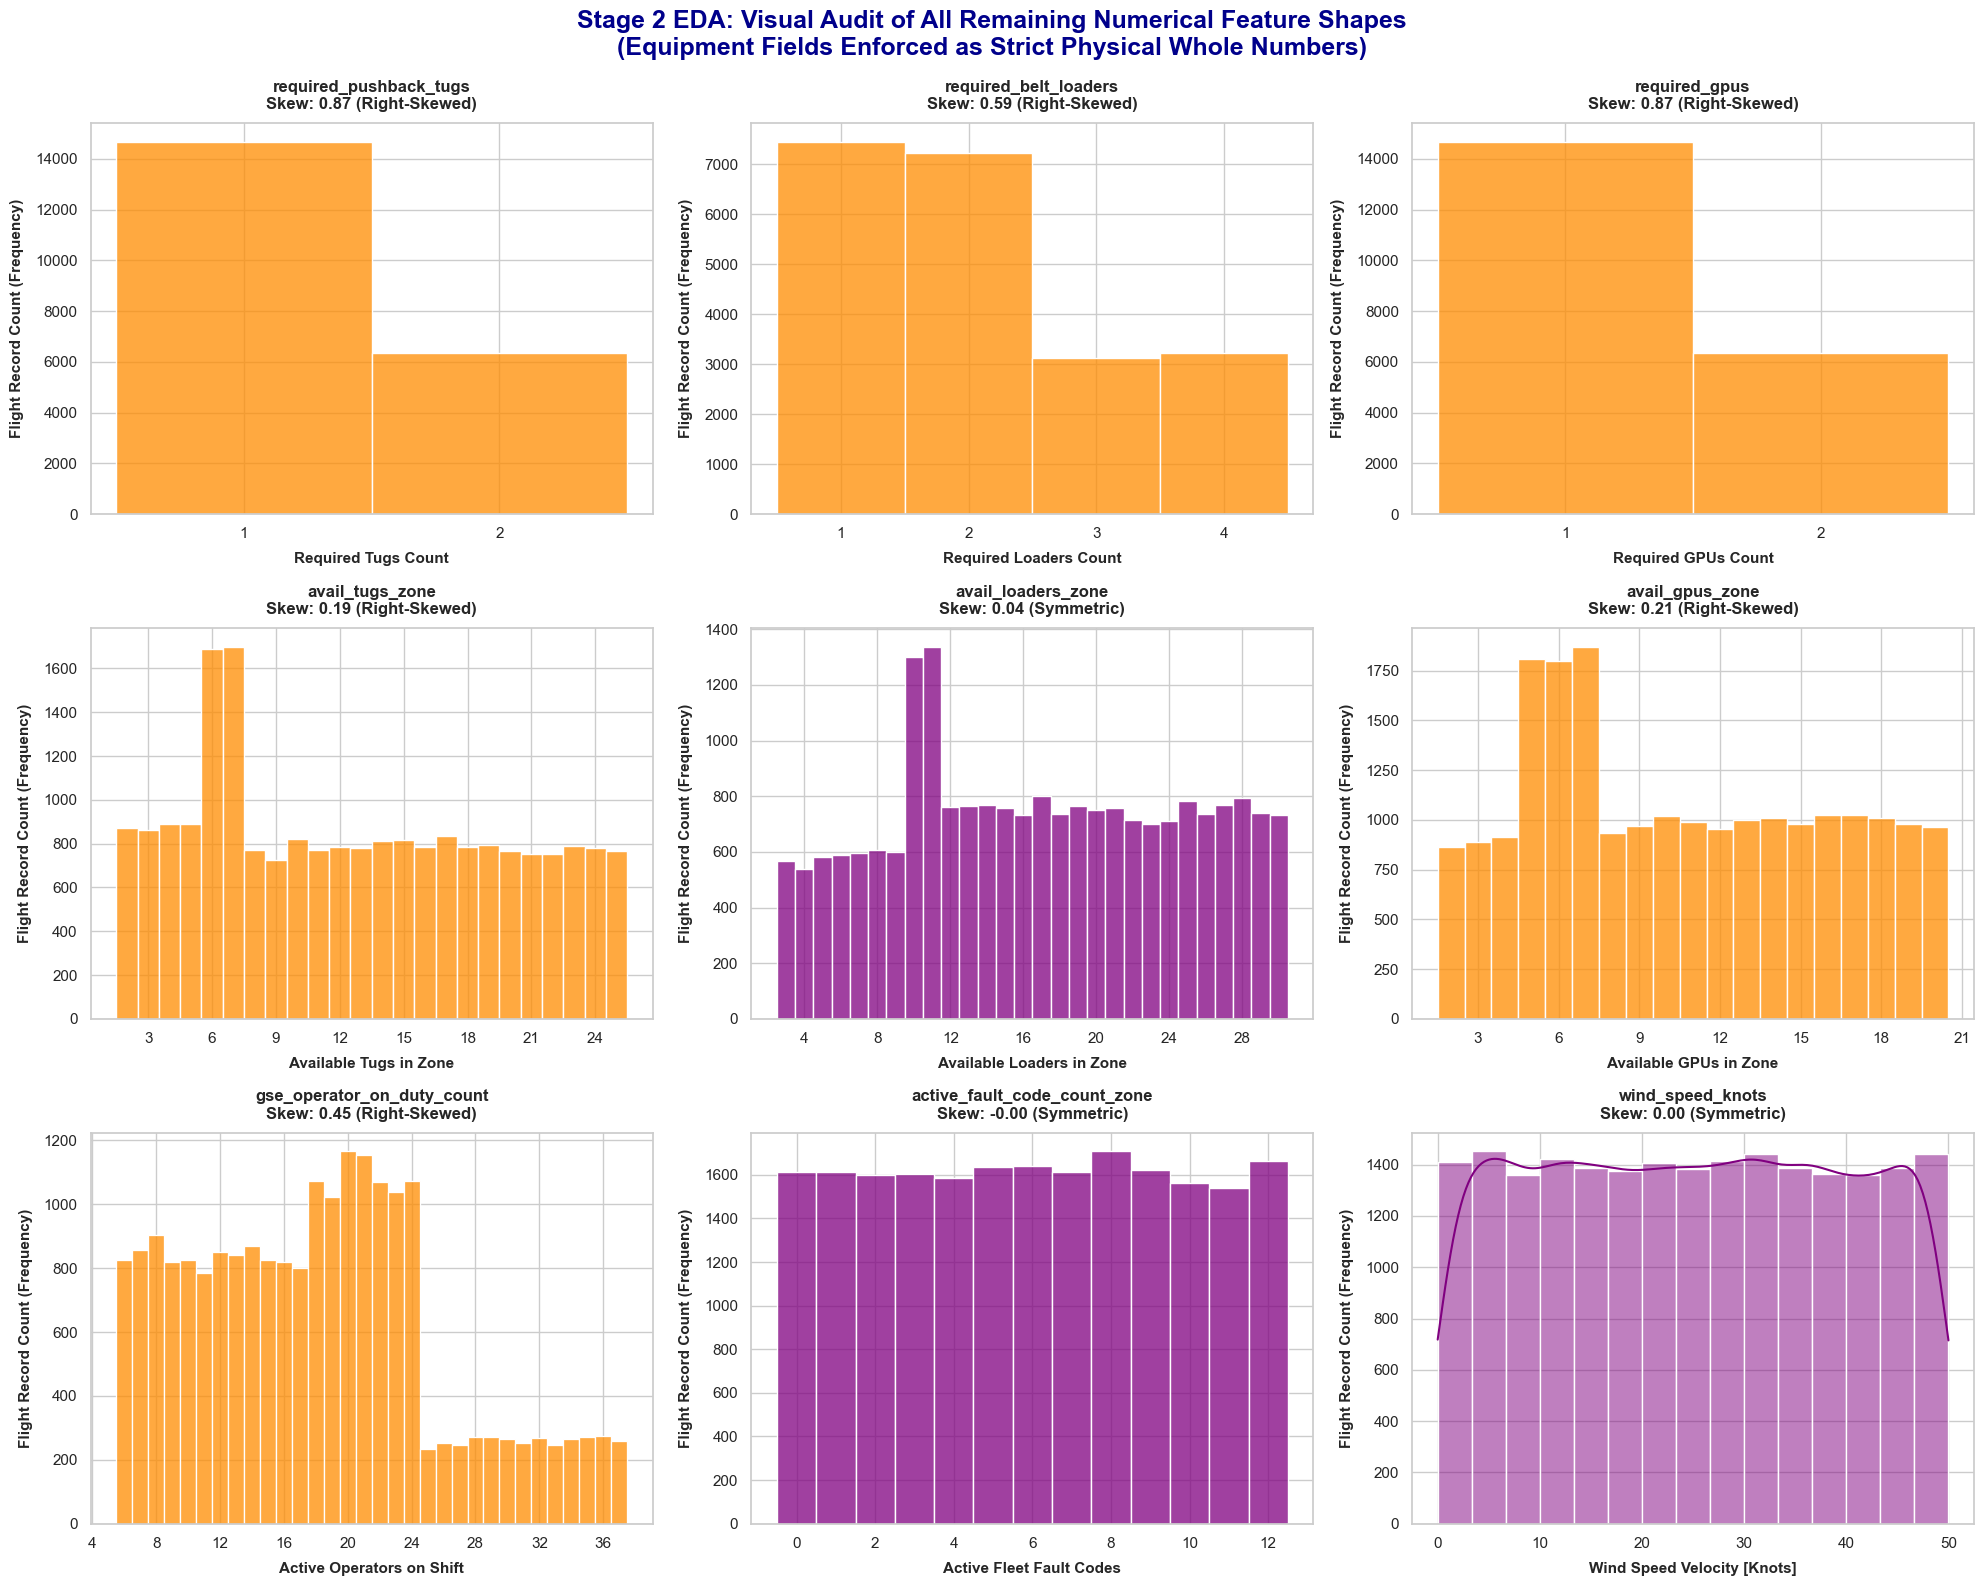

In [13]:
import matplotlib.ticker as ticker
# Map columns to their exact real-world X-axis descriptions
x_axis_labels = {
    'required_pushback_tugs': 'Required Tugs Count',
    'required_belt_loaders': 'Required Loaders Count',
    'required_gpus': 'Required GPUs Count',
    'avail_tugs_zone': 'Available Tugs in Zone',
    'avail_loaders_zone': 'Available Loaders in Zone',
    'avail_gpus_zone': 'Available GPUs in Zone',
    'gse_operator_on_duty_count': 'Active Operators on Shift',
    'active_fault_code_count_zone': 'Active Fleet Fault Codes',
    'wind_speed_knots': 'Wind Speed Velocity [Knots]'
}

# Identify which columns represent physical equipment count vs continuous data
continuous_cols = ['wind_speed_knots'] 

# Define the remaining numerical columns to visualize
remaining_numerical_cols = list(x_axis_labels.keys())

fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(remaining_numerical_cols):
    skew_val = train_df[col].skew()
    
    # Determine color theme based on asymmetry
    if abs(skew_val) < 0.1:
        plot_color, shape_type = 'purple', "Symmetric"
    elif skew_val > 0.1:
        plot_color, shape_type = 'darkorange', "Right-Skewed"
    else:
        plot_color, shape_type = 'teal', "Left-Skewed"
    
    # Use discrete bars for counts to keep columns perfectly centered over whole integers
    if col not in continuous_cols:
        sns.histplot(data=train_df, x=col, kde=False, ax=axes[i], color=plot_color, discrete=True)
        # FORCE X-AXIS TO DROP DECIMALS (No 1.5, 2.5)
        axes[i].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    else:
        # Wind can have natural decimals, so we keep standard bins and smooth trend lines
        sns.histplot(data=train_df, x=col, kde=True, ax=axes[i], color=plot_color, bins=15)
    
    # Set titles and structural operational labels for axes
    axes[i].set_title(f'{col}\nSkew: {skew_val:.2f} ({shape_type})', fontsize=12, weight='bold', pad=10)
    axes[i].set_xlabel(x_axis_labels[col], fontsize=11, weight='bold', labelpad=8)
    axes[i].set_ylabel('Flight Record Count (Frequency)', fontsize=11, weight='bold', labelpad=8)

# Clean up empty slots if the array layout changes
for j in range(len(remaining_numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Stage 2 EDA: Visual Audit of All Remaining Numerical Feature Shapes\n(Equipment Fields Enforced as Strict Physical Whole Numbers)', 
             fontsize=18, weight='bold', y=0.99, color='darkblue')
plt.tight_layout()
plt.show()

--- Step 1: Analyzing Categorical Features against Target ---


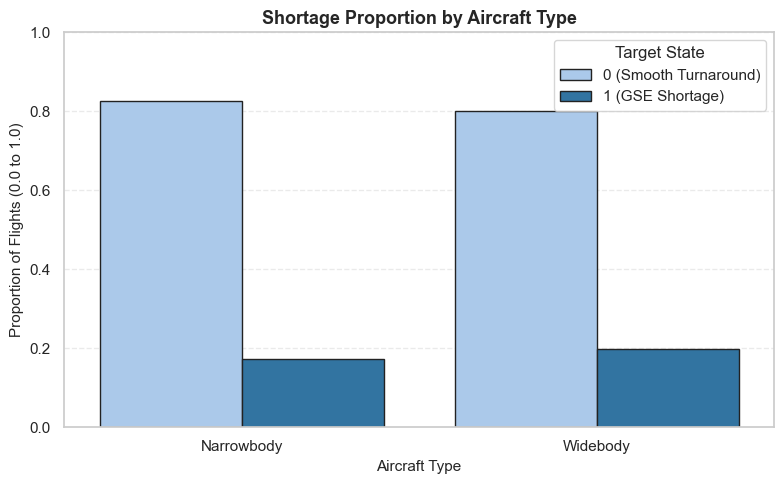

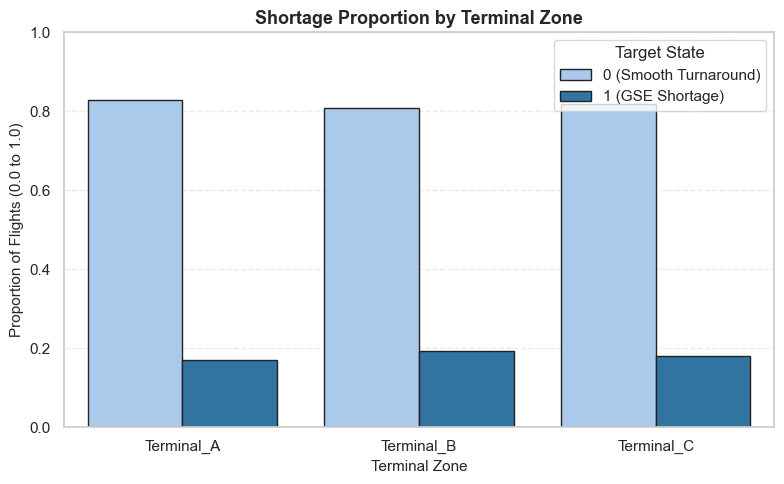


--- Step 2: Analyzing Numerical Features against Target ---


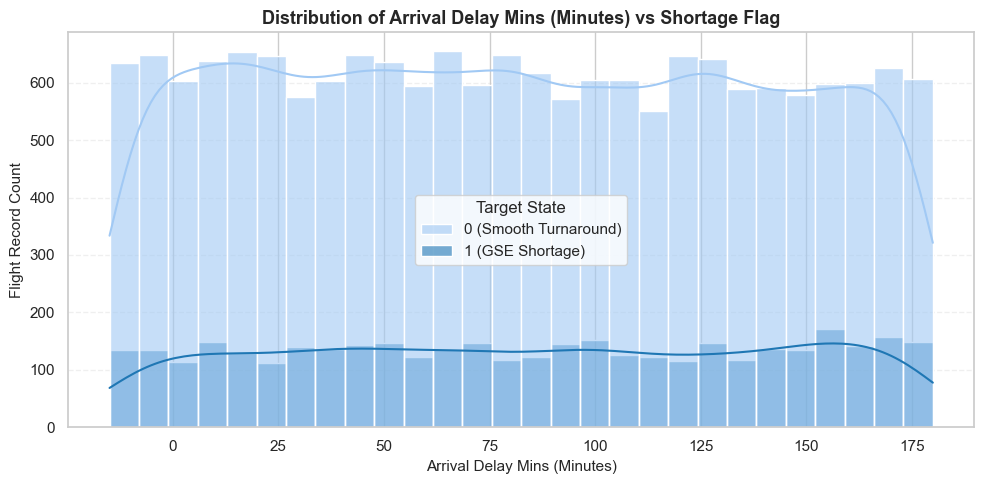

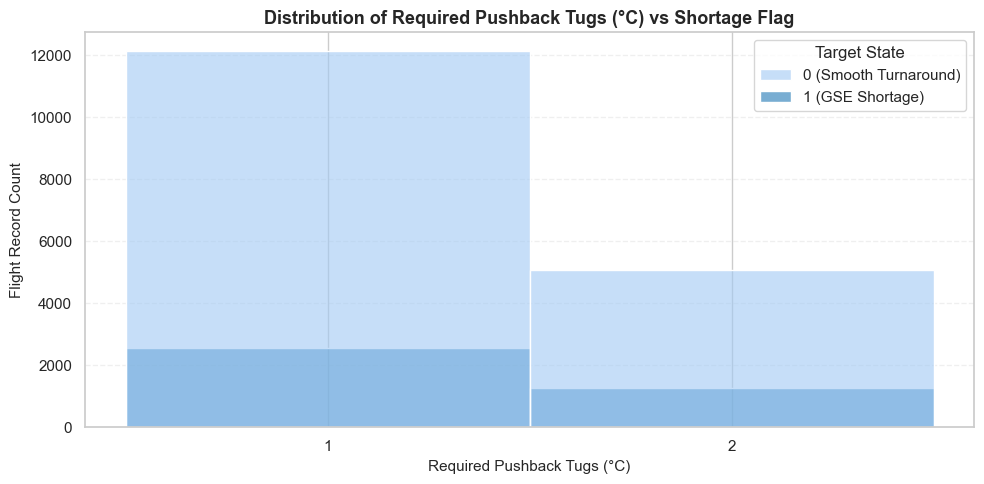

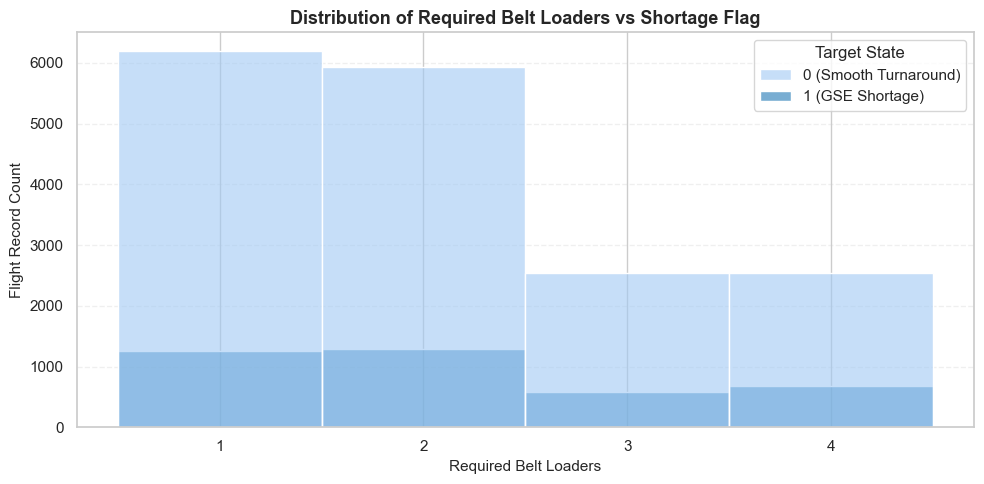

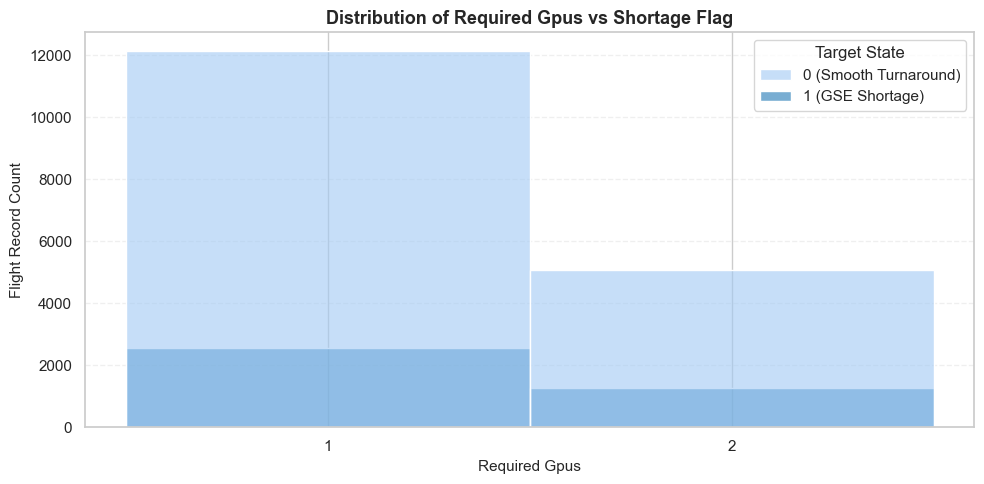

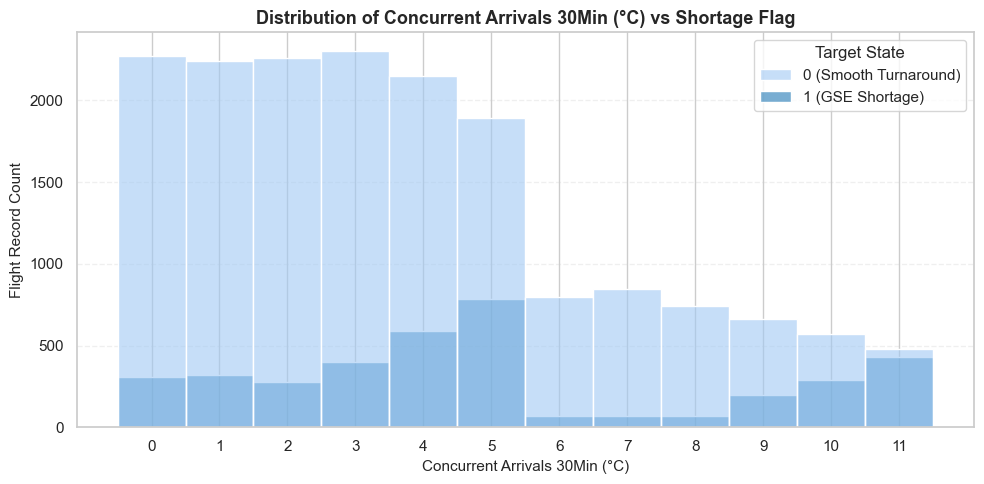

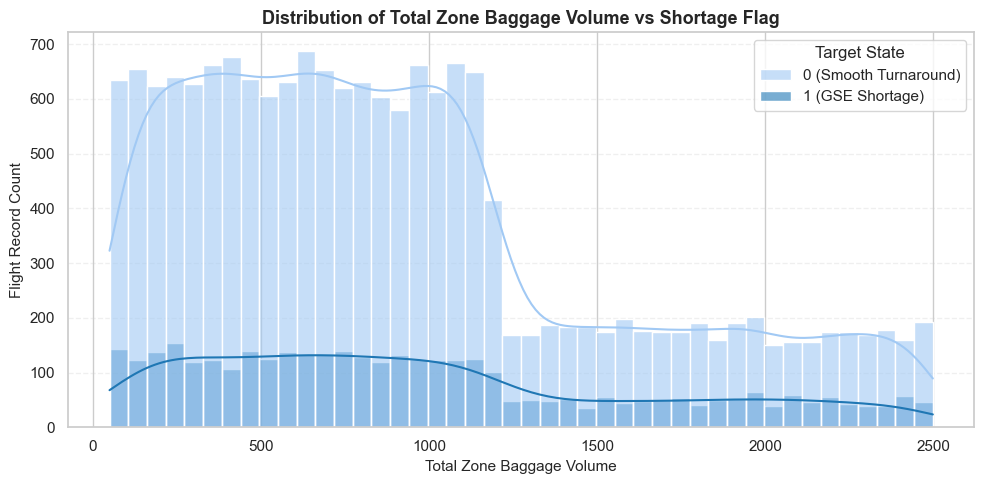

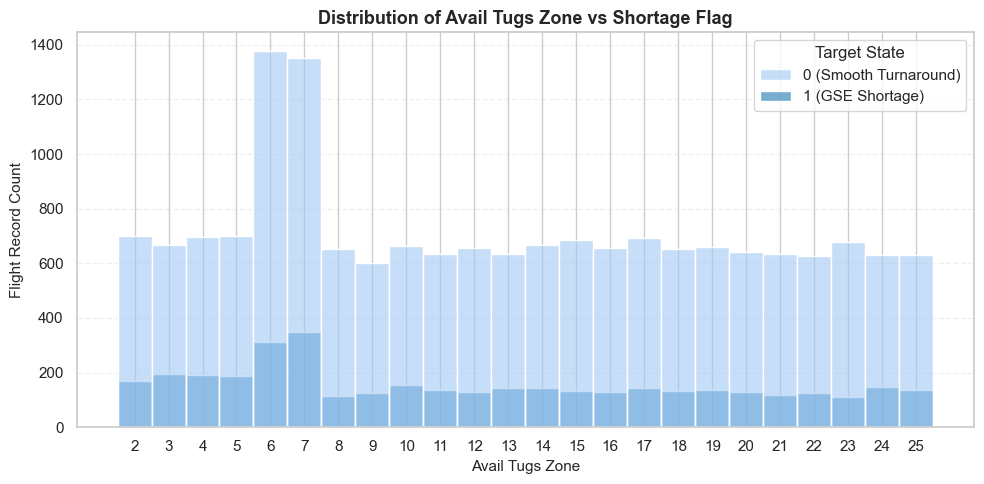

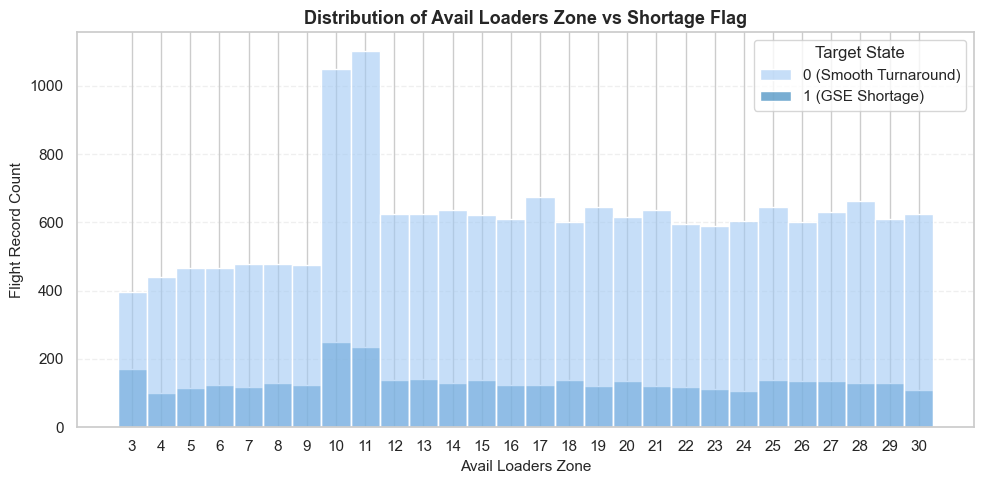

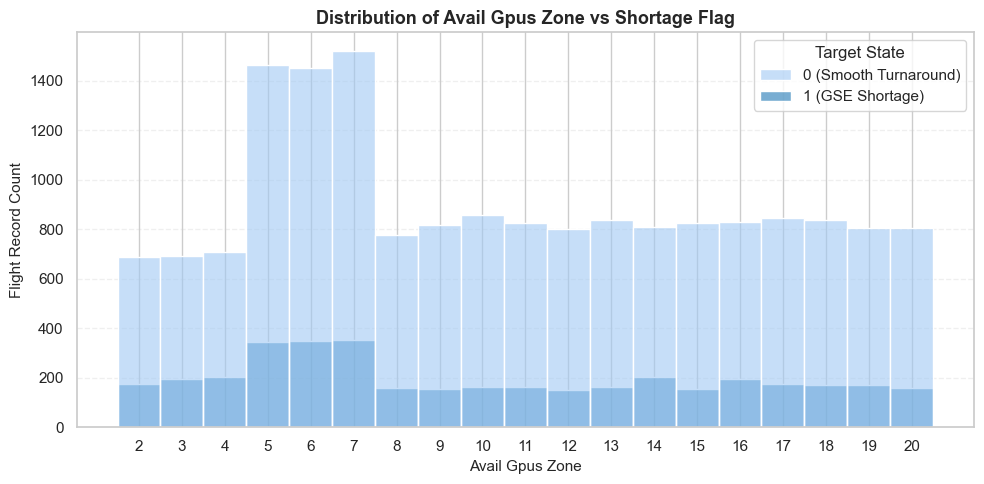

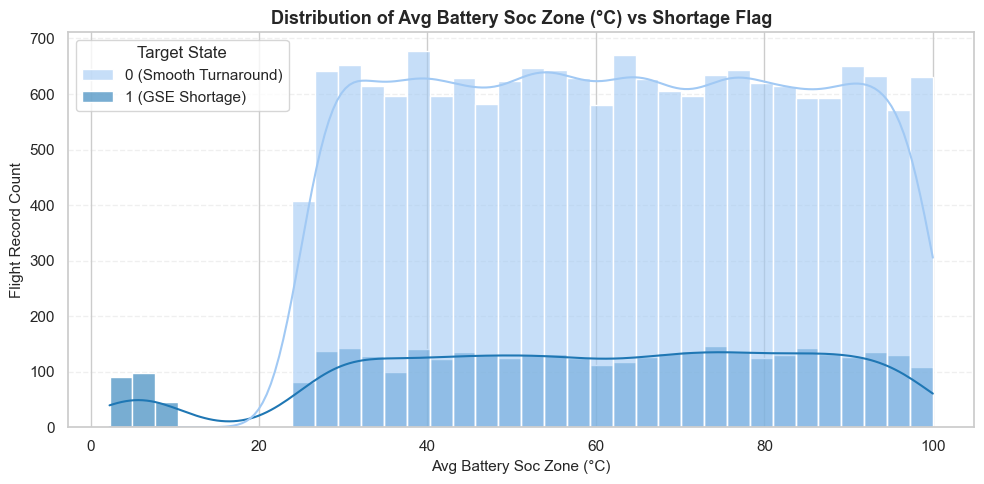

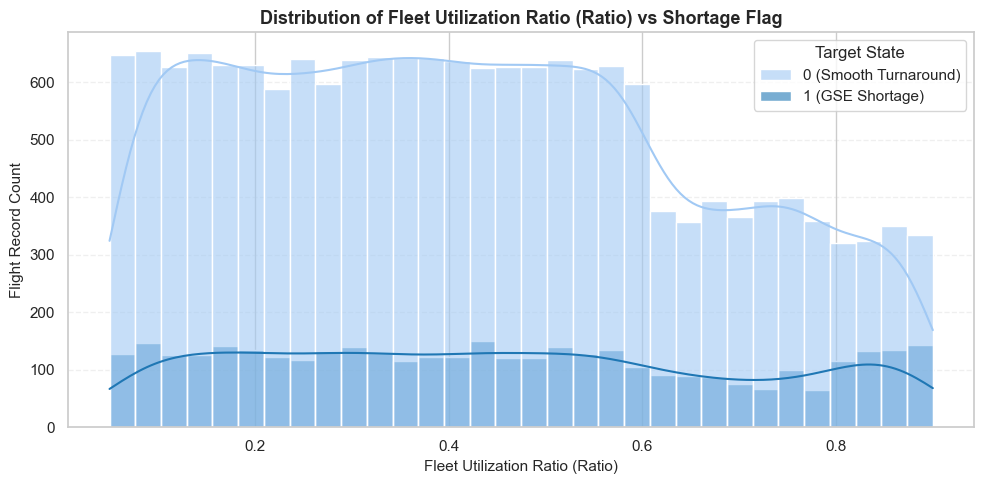

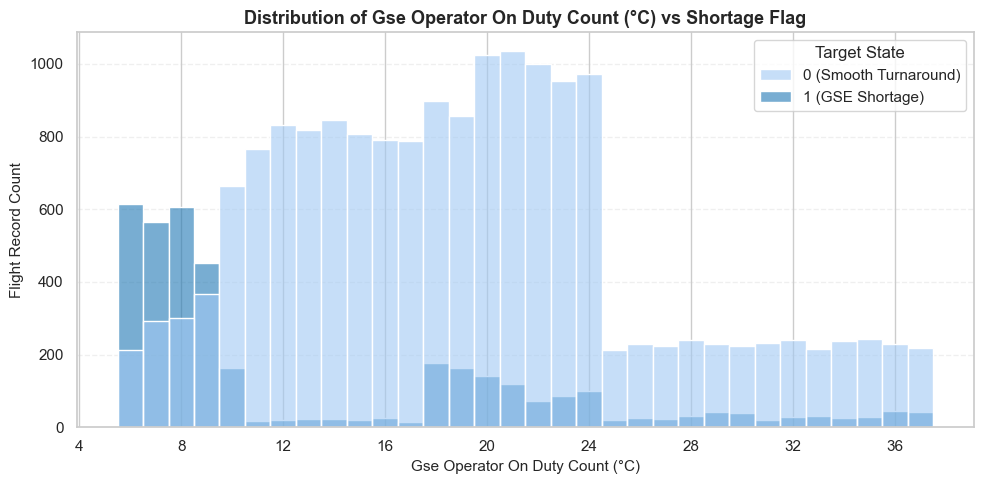

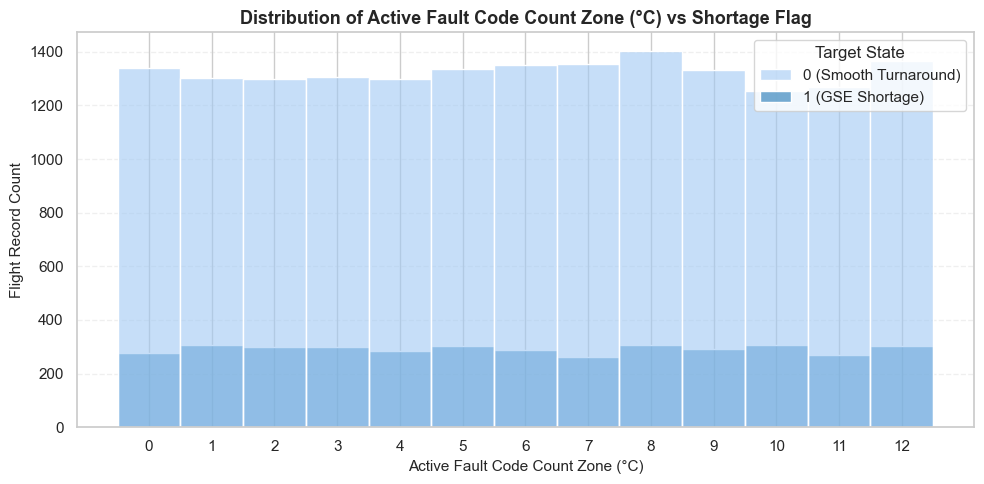

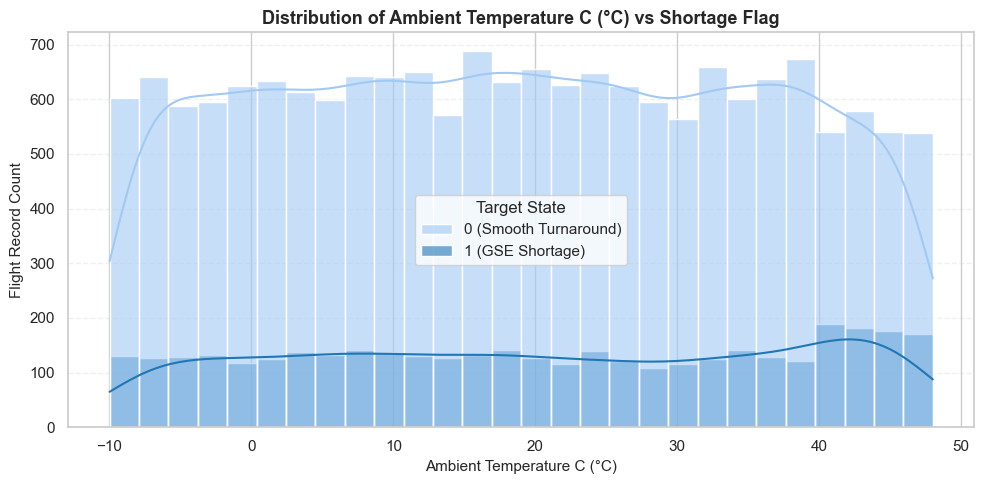

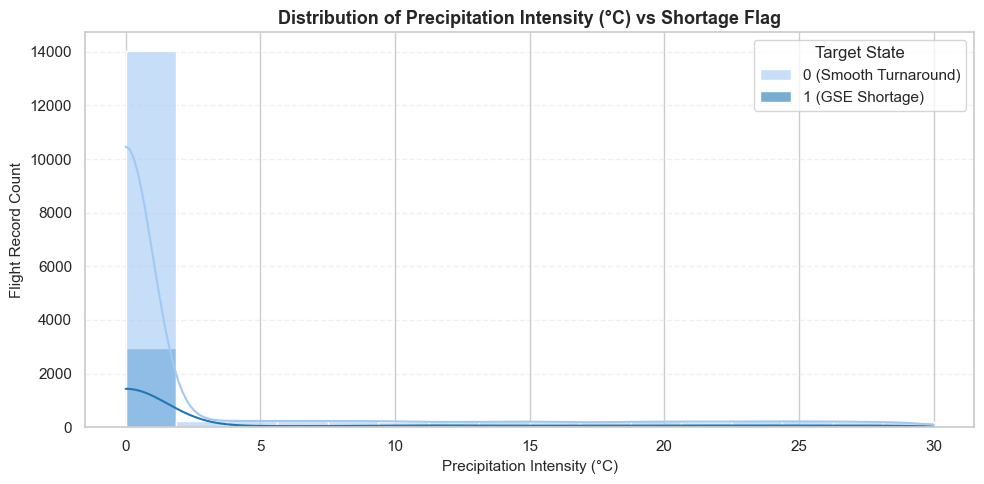

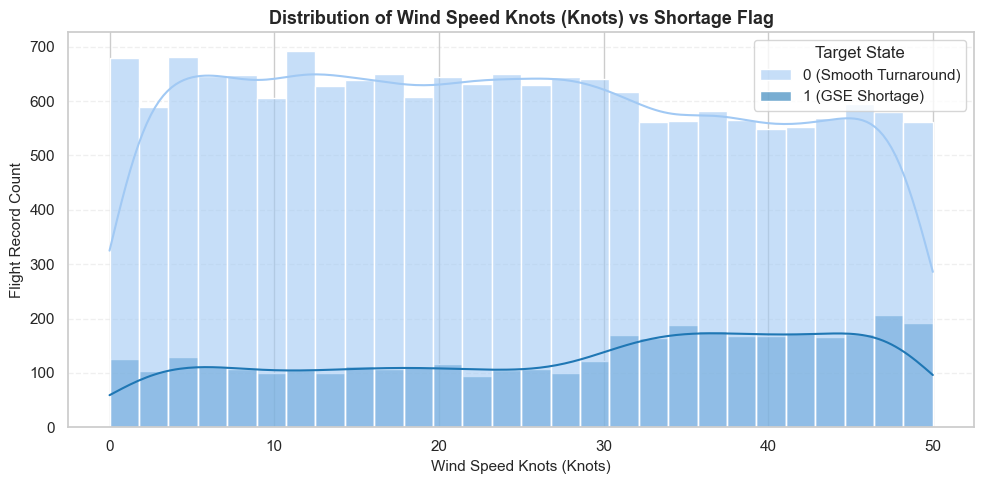

In [14]:
# Cell: Individual Feature Analysis against Target (Bivariate Profiling)
# 1. Define feature lists, explicitly omitting metadata columns to drop
metadata_cols = ['flight_id', 'actual_arrival_timestamp', 'gse_shortage_flag']
categorical_features = [col for col in train_df.select_dtypes(include=['object', 'category']).columns if col not in metadata_cols]
numerical_features = [col for col in train_df.select_dtypes(include=['int64', 'float64']).columns if col not in metadata_cols]

# 2. Modern Blue-Spectrum Palette (No Red/Green)
palette_colors = {
    0: "#a1c9f4",  # Soft Ice Blue (Smooth Turnaround)
    1: "#1f77b4"   # Solid Deep Blue (GSE Shortage)
}
labels_map = {0: "0 (Smooth Turnaround)", 1: "1 (GSE Shortage)"}

# Columns that represent discrete physical equipment counts or whole tallies
discrete_count_cols = [
    'required_pushback_tugs', 'required_belt_loaders', 'required_gpus', 
    'concurrent_arrivals_30min', 'avail_tugs_zone', 'avail_loaders_zone', 
    'avail_gpus_zone', 'gse_operator_on_duty_count', 'active_fault_code_count_zone'
]

print("--- Step 1: Analyzing Categorical Features against Target ---")
for col in categorical_features:
    plt.figure(figsize=(8, 5))
    
    # Calculate the exact proportion of shortages per category
    prop_df = train_df.groupby(col)['gse_shortage_flag'].value_counts(normalize=True).rename('percentage').reset_index()
    prop_df['gse_shortage_flag_label'] = prop_df['gse_shortage_flag'].map(labels_map)
    
    sns.barplot(
        data=prop_df, x=col, y='percentage', hue='gse_shortage_flag_label',
        palette={"0 (Smooth Turnaround)": "#a1c9f4", "1 (GSE Shortage)": "#1f77b4"}, edgecolor="#222222"
    )
    
    plt.title(f"Shortage Proportion by {col.replace('_', ' ').title()}", fontsize=13, fontweight='bold')
    plt.xlabel(col.replace('_', ' ').title(), fontsize=11)
    plt.ylabel("Proportion of Flights (0.0 to 1.0)", fontsize=11)
    plt.ylim(0, 1.0)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.legend(title="Target State", loc="upper right")
    plt.tight_layout()
    plt.show()

print("\n--- Step 2: Analyzing Numerical Features against Target ---")
for col in numerical_features:
    plt.figure(figsize=(10, 5))
    
    # Apply specific logic based on whether a column represents whole physical entities
    if col in discrete_count_cols:
        # Force strict integer bins and disable continuous smoothing lines (KDE)
        sns.histplot(
            data=train_df, x=col, hue='gse_shortage_flag', palette=palette_colors,
            multiple="layer", discrete=True, alpha=0.6, edgecolor="white"
        )
        # Ensure x-axis ticks are cleanly placed at whole number integers only
        min_val = int(train_df[col].min())
        max_val = int(train_df[col].max())
        # If the range is massive, let matplotlib scale automatically but keep integers
        if (max_val - min_val) <= 30:
            plt.xticks(range(min_val, max_val + 1))
        else:
            plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    else:
        # Standard continuous numeric columns (e.g. Temperature, Battery SOC)
        sns.histplot(
            data=train_df, x=col, hue='gse_shortage_flag', palette=palette_colors,
            multiple="layer", kde=True, alpha=0.6, edgecolor="white"
        )
    
    # Clean Axis Labels dynamically formatted
    clean_label = col.replace('_', ' ').title()
    if 'c' in col.lower() or 'temp' in col.lower():
        clean_label += " (°C)"
    elif 'mins' in col.lower():
        clean_label += " (Minutes)"
    elif 'knots' in col.lower():
        clean_label += " (Knots)"
    elif 'ratio' in col.lower() or 'soc' in col.lower():
        clean_label += " (%)" if 'soc' in col.lower() else " (Ratio)"
        
    plt.title(f"Distribution of {clean_label} vs Shortage Flag", fontsize=13, fontweight='bold')
    plt.xlabel(clean_label, fontsize=11)
    plt.ylabel("Flight Record Count", fontsize=11)
    
    # Secure proper legend texts manually
    if plt.gca().get_legend():
        legend = plt.gca().get_legend()
        legend.set_title("Target State")
        for t, text in zip(legend.get_texts(), [labels_map[0], labels_map[1]]):
            t.set_text(text)
            
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

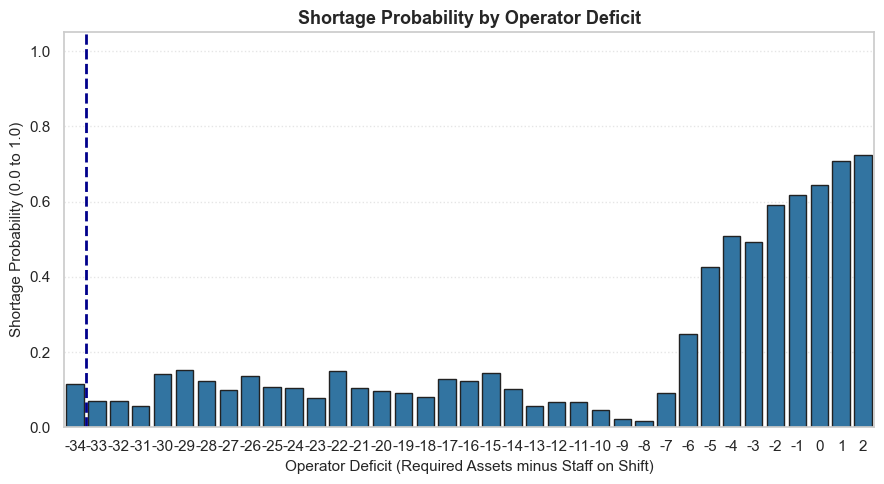

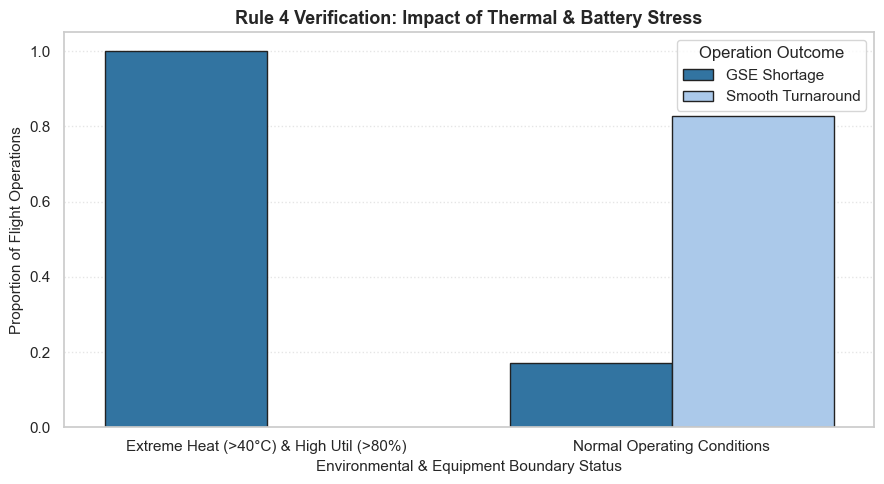

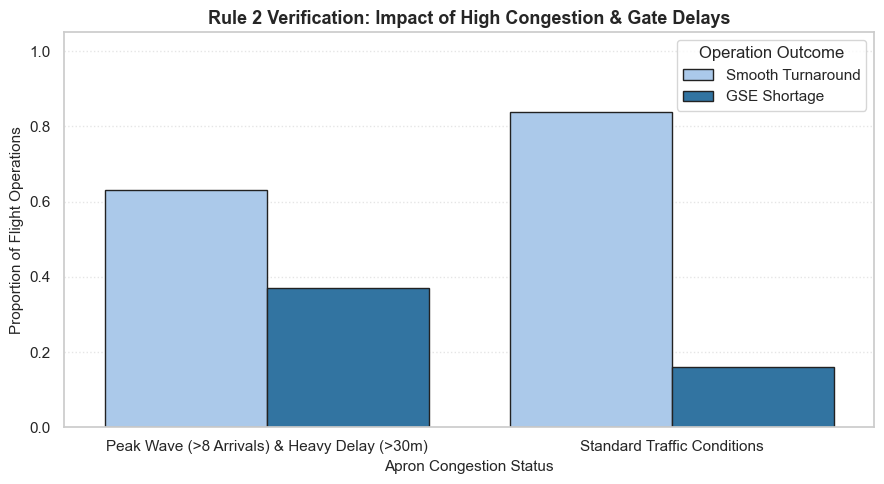

In [15]:
# 1. Compute basic operational metrics if not already done
train_df['total_asset_demand'] = (
    train_df['required_pushback_tugs'] + 
    train_df['required_belt_loaders'] + 
    train_df['required_gpus']
)
train_df['operator_deficit'] = train_df['total_asset_demand'] - train_df['gse_operator_on_duty_count']

# Create simple categorical buckets for complex rules to simplify the visualization
train_df['is_high_heat_and_util'] = (train_df['ambient_temperature_c'] > 40.0) & (train_df['fleet_utilization_ratio'] > 0.80)
train_df['is_congested_and_delayed'] = (train_df['arrival_delay_mins'] > 30) & (train_df['concurrent_arrivals_30min'] > 8)

# Mapping text for clarity
heat_util_map = {False: "Normal Operating Conditions", True: "Extreme Heat (>40°C) & High Util (>80%)"}
congestion_map = {False: "Standard Traffic Conditions", True: "Peak Wave (>8 Arrivals) & Heavy Delay (>30m)"}

train_df['thermal_stress_group'] = train_df['is_high_heat_and_util'].map(heat_util_map)
train_df['congestion_stress_group'] = train_df['is_congested_and_delayed'].map(congestion_map)

# Palette style (Clean modern blues)
bar_palette = {"Smooth Turnaround": "#a1c9f4", "GSE Shortage": "#1f77b4"}


# --- Chart 1: The Human Capital Bottleneck (Rule 1) ---
plt.figure(figsize=(9, 5))
# Show simple average shortage rate by deficit step
deficit_summary = train_df.groupby('operator_deficit')['gse_shortage_flag'].mean().reset_index()

sns.barplot(data=deficit_summary, x='operator_deficit', y='gse_shortage_flag', color="#1f77b4", edgecolor="#222222")
plt.axvline(x=0.5, color='darkblue', linestyle='--', linewidth=2)

plt.title("Shortage Probability by Operator Deficit", fontsize=13, fontweight='bold')
plt.xlabel("Operator Deficit (Required Assets minus Staff on Shift)", fontsize=11)
plt.ylabel("Shortage Probability (0.0 to 1.0)", fontsize=11)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


# --- Chart 2: Simplified Thermal Breakdown Risk (Rule 4) ---
plt.figure(figsize=(9, 5))
# Calculate clear proportions for the two groups
thermal_summary = train_df.groupby('thermal_stress_group')['gse_shortage_flag'].value_counts(normalize=True).rename('proportion').reset_index()
thermal_summary['Target State'] = thermal_summary['gse_shortage_flag'].map({0: "Smooth Turnaround", 1: "GSE Shortage"})

sns.barplot(
    data=thermal_summary, x='thermal_stress_group', y='proportion', hue='Target State',
    palette=bar_palette, edgecolor="#222222"
)
plt.title("Rule 4 Verification: Impact of Thermal & Battery Stress", fontsize=13, fontweight='bold')
plt.xlabel("Environmental & Equipment Boundary Status", fontsize=11)
plt.ylabel("Proportion of Flight Operations", fontsize=11)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.legend(title="Operation Outcome")
plt.tight_layout()
plt.show()


# --- Chart 3: Simplified Congestion Wave Rule (Rule 2) ---
plt.figure(figsize=(9, 5))
# Calculate clear proportions for the traffic surge groups
congestion_summary = train_df.groupby('congestion_stress_group')['gse_shortage_flag'].value_counts(normalize=True).rename('proportion').reset_index()
congestion_summary['Target State'] = congestion_summary['gse_shortage_flag'].map({0: "Smooth Turnaround", 1: "GSE Shortage"})

sns.barplot(
    data=congestion_summary, x='congestion_stress_group', y='proportion', hue='Target State',
    palette=bar_palette, edgecolor="#222222"
)
plt.title("Rule 2 Verification: Impact of High Congestion & Gate Delays", fontsize=13, fontweight='bold')
plt.xlabel("Apron Congestion Status", fontsize=11)
plt.ylabel("Proportion of Flight Operations", fontsize=11)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.legend(title="Operation Outcome")
plt.tight_layout()
plt.show()

# AutoGluon Framework 

-->Data Cleaning, Handling (not needed)

-->Data Preprocessing

-->Feature Engineering

-->Compare with multiple algorithm

**All handled by AutoGluon**

In [16]:
# Cell: AutoGluon Final Test Dataset Evaluation and Leaderboard (Fixed & Re-run Safe)

import os
from autogluon.tabular import TabularDataset, TabularPredictor

# =====================================================================
# STEP 1: LOAD RE-ISOLATED TEST DATASET
# =====================================================================
print("=== Step 1: Loading Test Dataset & Applying Drop Rules ===")

# Load the raw test file from the workspace directory
test_raw = pd.read_csv("gse_availability_test.csv")

# MANDATE: Isolate and drop administrative identifiers to avoid data leakage
cols_to_drop = ["flight_id"]
test_clean = test_raw.drop(columns=cols_to_drop, errors='ignore')
test_data = TabularDataset(test_clean)

print(f"Total row matrices loaded for final test validation: {len(test_data)}\n")

# =====================================================================
# STEP 2: RE-LOAD PERSISTED TABULARPREDICTOR MODEL FROM DISK
# =====================================================================
print("=== Step 2: Accessing Trained Predictor From Workspace ===")

target_col = "gse_shortage_flag"
fresh_model_dir = "ag_models_gse_shortage_classification"

# RE-LOAD OPERATION: This reads the saved model directly from your hard drive folder
# This makes sure the cell runs perfectly even if your notebook session expired!
predictor = TabularPredictor.load(fresh_model_dir)

# =====================================================================
# STEP 3: FINAL METRICS GENERATION & LEADERBOARD SCORE STANDINGS
# =====================================================================
print("=== Step 3: Running Test Sweep and Extracting Standings ===\n")

# 1. Retrieve the entire leaderboard using the unseen test dataset
leaderboard = predictor.leaderboard(test_data, silent=True)

# 2. Extract comprehensive evaluation metrics on the test dataset
performance_metrics = predictor.evaluate(test_data, silent=True)

# RECTIFIED LINE: Fixed the method call to the correct attribute property (.model_best)
best_model_name = predictor.model_best

# PRINT REPORTING REQUIREMENTS
print("==========================================================")
print("                    FINAL REPORT CARD                     ")
print("==========================================================")
print(f"🏆 WINNING ALGORITHM: {best_model_name}\n")

print("--- PERFORMANCE METRICS ON TEST DATA ---")
for metric_name, score in performance_metrics.items():
    print(f"  {metric_name.upper()}: {score:.4f}")

print("\n--- ALL TRAINED MODELS STANDINGS (Sorted by ROC-AUC Score) ---")
print(leaderboard[['model', 'score_test', 'score_val', 'stack_level']].to_string(index=False))
print("==========================================================")

=== Step 1: Loading Test Dataset & Applying Drop Rules ===
Total row matrices loaded for final test validation: 4500

=== Step 2: Accessing Trained Predictor From Workspace ===
=== Step 3: Running Test Sweep and Extracting Standings ===

                    FINAL REPORT CARD                     
🏆 WINNING ALGORITHM: WeightedEnsemble_L3

--- PERFORMANCE METRICS ON TEST DATA ---
  ROC_AUC: 0.9493
  ACCURACY: 0.9829
  BALANCED_ACCURACY: 0.9534
  MCC: 0.9419
  F1: 0.9506
  PRECISION: 0.9987
  RECALL: 0.9070

--- ALL TRAINED MODELS STANDINGS (Sorted by ROC-AUC Score) ---
                  model  score_test  score_val  stack_level
        LightGBM_BAG_L1    0.954445   0.947751            1
         XGBoost_BAG_L1    0.953988   0.945899            1
RandomForestGini_BAG_L1    0.953927   0.944692            1
RandomForestEntr_BAG_L1    0.952908   0.943901            1
 NeuralNetFastAI_BAG_L2    0.952047   0.948738            2
RandomForestGini_BAG_L2    0.951703   0.946126            2
 Neural

# Traditional method

-->Temporal Feature Extraction

In [17]:
# Cell: Traditional Pipeline - Task 1: Temporal Feature Extraction


print("=== Extracting Operational Shifts and Temporal Flags ===")

# 1. Load the original raw splits
train_raw = pd.read_csv("gse_availability_train.csv")
val_raw = pd.read_csv("gse_availability_validation.csv")
test_raw = pd.read_csv("gse_availability_test.csv")

=== Extracting Operational Shifts and Temporal Flags ===


-->Handling Skeweness

In [18]:
# Cell: Traditional Pipeline - Task 2: Baseline Continuous Distribution Verification

print("=== Task 2: Verifying Continuous Feature Layouts ===")

# Leaving all continuous variables in their raw, native scales 
# Tree-based algorithms naturally handle non-linear scaling without distortion.
train_transformed = train_raw.copy()
test_transformed = test_raw.copy()

print("\n--- Baseline Feature Skewness Reference ---")
print(f"Arrival Delay Skewness: {train_transformed['arrival_delay_mins'].skew():.4f}")
print(f"Wind Speed Skewness:    {train_transformed['wind_speed_knots'].skew():.4f}")
print(f"Precipitation Skew:     {train_transformed['precipitation_intensity'].skew():.4f}")

=== Task 2: Verifying Continuous Feature Layouts ===

--- Baseline Feature Skewness Reference ---
Arrival Delay Skewness: 0.0177
Wind Speed Skewness:    0.0042
Precipitation Skew:     2.3296


-->Categorical Encoding

In [19]:
# Cell: Traditional Pipeline - Task 3: One-Hot Categorical Encoding


print("===  Implementing One-Hot Encoding for Custom Feature Matrices ===")

# 1. Define the categorical columns requiring binary structural expansion
categorical_features = ["aircraft_type", "terminal_zone"]

# 2. Isolate features and target columns for both sets
target_col = "gse_shortage_flag"
cols_to_drop = ["flight_id", "actual_arrival_timestamp", target_col]

y_train = train_transformed[target_col].reset_index(drop=True)
X_train_raw = train_transformed.drop(columns=cols_to_drop, errors='ignore')

y_test = test_transformed[target_col].reset_index(drop=True)
X_test_raw = test_transformed.drop(columns=cols_to_drop, errors='ignore')

# 3. Apply One-Hot Encoding to expand categories into distinct binary columns (0 or 1)
X_train_encoded = pd.get_dummies(X_train_raw, columns=categorical_features, drop_first=False)
X_test_encoded = pd.get_dummies(X_test_raw, columns=categorical_features, drop_first=False)

# 4. Critical Alignment: Align columns to guarantee identical shapes between Train and Test sets
X_train, X_test = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# Convert boolean True/False outputs from get_dummies to integers (1/0)
X_train = X_train.astype(float)
X_test = X_test.astype(float)

print("✔️ Categorical feature arrays expanded and aligned perfectly.")
print(f"Final Traditional Train Matrix Shape: {X_train.shape}")
print(f"Final Traditional Test Matrix Shape:  {X_test.shape}")
print(f"\nEngineered feature matrix column names:\n{list(X_train.columns)}")

===  Implementing One-Hot Encoding for Custom Feature Matrices ===
✔️ Categorical feature arrays expanded and aligned perfectly.
Final Traditional Train Matrix Shape: (21000, 21)
Final Traditional Test Matrix Shape:  (4500, 21)

Engineered feature matrix column names:
['arrival_delay_mins', 'required_pushback_tugs', 'required_belt_loaders', 'required_gpus', 'concurrent_arrivals_30min', 'total_zone_baggage_volume', 'avail_tugs_zone', 'avail_loaders_zone', 'avail_gpus_zone', 'avg_battery_soc_zone', 'fleet_utilization_ratio', 'gse_operator_on_duty_count', 'active_fault_code_count_zone', 'ambient_temperature_c', 'precipitation_intensity', 'wind_speed_knots', 'aircraft_type_Narrowbody', 'aircraft_type_Widebody', 'terminal_zone_Terminal_A', 'terminal_zone_Terminal_B', 'terminal_zone_Terminal_C']


-->Grid search and Hyper parameter tuning

In [20]:
# Cell: Traditional Pipeline - Task 4: Unified Multi-Model Grid Search & Ensembling
print("=== Task 4: Initializing Multi-Model Optimization Loop ===")

# 1. Define the base configurations for all 4 traditional candidate engines
models_config = {
    "XGBoost": {
        "estimator": XGBClassifier(n_estimators=200, subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='logloss'),
        "grid": {'max_depth': [4, 6], 'learning_rate': [0.05, 0.1]}
    },
    "LightGBM": {
        "estimator": LGBMClassifier(n_estimators=200, subsample=0.8, random_state=42, verbose=-1),
        "grid": {'num_leaves': [31, 63], 'learning_rate': [0.05, 0.1]}
    },
    "CatBoost": {
        "estimator": CatBoostClassifier(iterations=200, random_state=42, verbose=0),
        "grid": {'depth': [4, 6], 'learning_rate': [0.05, 0.1]}
    },
    "ExtraTrees": {
        "estimator": ExtraTreesClassifier(n_estimators=200, random_state=42),
        "grid": {'max_depth': [10, 20], 'min_samples_split': [2, 5]}
    }
}

best_estimators = []
leaderboard_records = []

# 2. Execute parallel grid sweeps sequentially across the models
for name, config in models_config.items():
    print(f"  -> Tuning {name}...")
    start = time.time()
    
    grid_search = GridSearchCV(
        estimator=config["estimator"],
        param_grid=config["grid"],
        cv=3,
        scoring='roc_auc',
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    elapsed = time.time() - start
    
    # Store optimized models and capture evaluation records
    best_estimators.append((name, grid_search.best_estimator_))
    leaderboard_records.append({
        "Model": name,
        "Best_Validation_ROC_AUC": grid_search.best_score_,
        "Optimal_Params": grid_search.best_params_,
        "Tuning_Time_Sec": round(elapsed, 2)
    })

# 3. Create a Traditional Manual Ensemble (Soft Voting based on averaged probabilities)
print("  -> Constructing Final Blender (Soft Voting Classifier)...")
voting_ensemble = VotingClassifier(estimators=best_estimators, voting='soft', n_jobs=-1)
voting_ensemble.fit(X_train, y_train)

# 4. Compile and display the Traditional Leaderboard Results
traditional_leaderboard = pd.DataFrame(leaderboard_records).sort_values(by="Best_Validation_ROC_AUC", ascending=False)

print("\n==========================================================")
print("             TRADITIONAL TUNING LEADERBOARD               ")
print("==========================================================")
print(traditional_leaderboard.to_string(index=False))
print("==========================================================")
print("✔️ All 4 models optimized and integrated into 'voting_ensemble' object.")

=== Task 4: Initializing Multi-Model Optimization Loop ===
  -> Tuning XGBoost...
  -> Tuning LightGBM...
  -> Tuning CatBoost...
  -> Tuning ExtraTrees...
  -> Constructing Final Blender (Soft Voting Classifier)...

             TRADITIONAL TUNING LEADERBOARD               
     Model  Best_Validation_ROC_AUC                            Optimal_Params  Tuning_Time_Sec
  CatBoost                 0.948759        {'depth': 6, 'learning_rate': 0.1}             9.79
  LightGBM                 0.947979  {'learning_rate': 0.1, 'num_leaves': 31}            23.51
   XGBoost                 0.947140    {'learning_rate': 0.1, 'max_depth': 6}            39.85
ExtraTrees                 0.946486 {'max_depth': 20, 'min_samples_split': 2}             8.83
✔️ All 4 models optimized and integrated into 'voting_ensemble' object.


In [32]:
import pickle

model_package = {
    "model": voting_ensemble,
    "feature_columns": list(X_train.columns),
    "categorical_features": [
        "aircraft_type",
        "terminal_zone"
    ],
    "target_column": "gse_shortage_flag"
}

with open("gse_traditional_model.pkl", "wb") as f:
    pickle.dump(model_package, f)

print("✅ Traditional Voting Ensemble saved.")

✅ Traditional Voting Ensemble saved.


-->Testing on unseen data

In [21]:
# Cell: Traditional Pipeline - Task 5: Final Test Evaluation Metrics

print("=== Generating Comprehensive Test Metrics ===")

# 1. Create a dictionary containing all our trained assets
trained_models = {
    "CatBoost (Tuned)": best_estimators[2][1],     # CatBoost instance
    "LightGBM (Tuned)": best_estimators[1][1],     # LightGBM instance
    "XGBoost (Tuned)": best_estimators[0][1],      # XGBoost instance
    "ExtraTrees (Tuned)": best_estimators[3][1],   # ExtraTrees instance
    "Traditional Voting Ensemble": voting_ensemble # The blended weighted model
}

test_metrics_records = []

# 2. Loop through each model to calculate its full report card on unseen test data
for name, model in trained_models.items():
    # Predict probabilities for ROC-AUC
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    # Predict hard binary labels for the remaining classification metrics
    y_pred = model.predict(X_test)
    
    test_metrics_records.append({
        "Model Architecture": name,
        "ROC_AUC": round(roc_auc_score(y_test, y_pred_proba), 4),
        "ACCURACY": round(accuracy_score(y_test, y_pred), 4),
        "BALANCED_ACC": round(balanced_accuracy_score(y_test, y_pred), 4),
        "F1_SCORE": round(f1_score(y_test, y_pred), 4),
        "PRECISION": round(precision_score(y_test, y_pred), 4),
        "RECALL": round(recall_score(y_test, y_pred), 4),
        "MCC": round(matthews_corrcoef(y_test, y_pred), 4)
    })

# 3. Display the final comparison grid
final_metrics_df = pd.DataFrame(test_metrics_records).sort_values(by="ROC_AUC", ascending=False)

print("\n==========================================================================================")
print("                               TRADITIONAL TEST METRICS REPORT                            ")
print("==========================================================================================")
print(final_metrics_df.to_string(index=False))
print("==========================================================================================")

=== Generating Comprehensive Test Metrics ===

                               TRADITIONAL TEST METRICS REPORT                            
         Model Architecture  ROC_AUC  ACCURACY  BALANCED_ACC  F1_SCORE  PRECISION  RECALL    MCC
           LightGBM (Tuned)   0.9512    0.9827        0.9527    0.9499     0.9987  0.9058 0.9411
            XGBoost (Tuned)   0.9496    0.9816        0.9506    0.9467     0.9959  0.9021 0.9372
Traditional Voting Ensemble   0.9468    0.9822        0.9525    0.9487     0.9960  0.9058 0.9395
         ExtraTrees (Tuned)   0.9460    0.9556        0.8805    0.8617     0.9905  0.7625 0.8459
           CatBoost (Tuned)   0.9447    0.9820        0.9519    0.9480     0.9960  0.9045 0.9388


-->Saving in pkl file